## Acknowledgements
Notebook is based on:
Can Yang & Gyozo Gidofalvi (2018) Fast map matching, an algorithm
integrating hidden Markov model with precomputation, International Journal of Geographical Information Science, 32:3, 547-570, DOI: 10.1080/13658816.2017.1400548

In [1]:
import osmnx as ox
import os
import time
from shapely.geometry import Polygon
from shapely.geometry import Point, LineString
import shapely.wkt
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

# Static Vairables

In [2]:
MASK = gpd.read_file("Data/Banks_Mask_Buffered.gpkg").to_crs(epsg=2193)
SALT = 741
FOOT_CYCLE_ONLY = {
    "track",
    "path",
    "cycleway",
    "footway"
}

In [3]:
def save_graph_shapefile_directional(G, filepath=None, encoding="utf-8"):
    os.makedirs(filepath, exist_ok=True)
    filepath_nodes = os.path.join(filepath, "nodes.shp")
    filepath_edges = os.path.join(filepath, "edges.shp")

    # convert undirected graph to gdfs and stringify non-numeric columns
    gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
    gdf_nodes = ox.io._stringify_nonnumeric_cols(gdf_nodes)
    gdf_edges = ox.io._stringify_nonnumeric_cols(gdf_edges)

    # We need an unique ID for each edge
    gdf_edges["fid"] = np.arange(0, gdf_edges.shape[0], dtype='int')
    # save the nodes and edges as separate ESRI shapefiles
    gdf_nodes.to_file(filepath_nodes, encoding=encoding)
    gdf_edges.to_file(filepath_edges, encoding=encoding)

    return gdf_edges, gdf_nodes

In [52]:
network_filters = {
    "all": None,
    "A": '["highway"~"track|path|cycleway|footway"]',
}

for filter_name, filter_value in network_filters.items():
    graph_kwargs = {
        "network_type": "all",
        "retain_all": True,
    }
    if filter_value is not None:
        graph_kwargs["custom_filter"] = filter_value

    G = ox.graph_from_polygon(
        MASK.to_crs(epsg=4326).geometry[0],
        **graph_kwargs,
    )
    G = ox.project_graph(G, to_crs='epsg:2193')
    gdf_edges, gdf_nodes = save_graph_shapefile_directional(G, filepath=f"Data/Map_Matching/Graph_Filter_{filter_name}")
    gdf_edges = gdf_edges.reset_index()
    gdf_edges = gdf_edges[['u','v','osmid','highway','geometry']]
    gdf_edges.to_file(f"Data/Supplementaries/{filter_name}_Edges.gpkg", driver="GPKG")

C:\Users\maxwe\AppData\Local\Temp\ipykernel_28060\1149002092.py:14: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_nodes.to_file(filepath_nodes, encoding=encoding)
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
C:\Users\maxwe\AppData\Local\Temp\ipykernel_28060\1149002092.py:14: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_nodes.to_file(filepath_nodes, encoding=encoding)
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


In [11]:
edges = gpd.read_file("Data/Map_Matching/Graph_Filter_all/edges.shp").to_crs(epsg=2193)
all_edges = gpd.read_file("Data/Supplementaries/all_Edges.gpkg")

In [18]:
import pandas as pd
import geopandas as gpd

# 1) Build undirected pairs from all_edges and keep source row indexes.
ae = all_edges.reset_index().rename(columns={"index": "all_edges_idx"}).copy()
ae["undirected_u"] = ae[["u", "v"]].min(axis=1)
ae["undirected_v"] = ae[["u", "v"]].max(axis=1)

group_cols = ["undirected_u", "undirected_v"]
agg_map = {
    col: "first"
    for col in ae.columns
    if col not in {"all_edges_idx", "undirected_u", "undirected_v"}
}
agg_map["all_edges_idx"] = lambda s: list(s)

unidirectional_edges = (
    ae.groupby(group_cols, as_index=False)
    .agg(agg_map)
    .rename(columns={"all_edges_idx": "edge_id"})
)

# 2) Pull relevant RDBPT columns from edges using the same undirected key.
rdbpt_cols = [c for c in edges.columns if "rdbpt" in c.lower()]
if rdbpt_cols:
    ed = edges.copy()
    ed["undirected_u"] = ed[["u", "v"]].min(axis=1)
    ed["undirected_v"] = ed[["u", "v"]].max(axis=1)

    def unique_values(series):
        vals = [v for v in pd.unique(series) if pd.notna(v)]
        return vals

    rdbpt_by_pair = (
        ed.groupby(group_cols, as_index=False)[rdbpt_cols]
        .agg(unique_values)
    )

    # Flatten single-value lists to scalars for cleaner output.
    for col in rdbpt_cols:
        rdbpt_by_pair[col] = rdbpt_by_pair[col].apply(
            lambda x: x[0] if isinstance(x, list) and len(x) == 1 else x
        )

    unidirectional_edges = unidirectional_edges.merge(
        rdbpt_by_pair,
        on=group_cols,
        how="left",
    )

# Standardize direction to undirected node order.
unidirectional_edges["u"] = unidirectional_edges["undirected_u"]
unidirectional_edges["v"] = unidirectional_edges["undirected_v"]
unidirectional_edges = unidirectional_edges.drop(columns=["undirected_u", "undirected_v"])

# 3) Keep all rows and report pair diagnostics.
unidirectional_edges["edge_count"] = unidirectional_edges["edge_id"].apply(len)
count_summary = unidirectional_edges["edge_count"].value_counts().sort_index()
print("edge_count summary:")
print(count_summary)

not_two = int((unidirectional_edges["edge_count"] != 2).sum())
if not_two:
    print(f"Rows without exactly two source edge indexes: {not_two}")

unidirectional_edges = gpd.GeoDataFrame(
    unidirectional_edges,
    geometry="geometry",
    crs=all_edges.crs,
)

out_path = "Data/Supplementaries/unidirectional_edges.gpkg"
unidirectional_edges.to_file(out_path, driver="GPKG")

print(f"Saved {len(unidirectional_edges):,} rows to {out_path}")
unidirectional_edges.head()

edge_count summary:
edge_count
1     411
2    7445
3      22
4     160
Name: count, dtype: int64
Rows without exactly two source edge indexes: 593
Saved 8,038 rows to Data/Supplementaries/unidirectional_edges.gpkg


,u,v,osmid,highway,geometry,edge_id,RDBPT_Sub,RDBPT_Num,edge_count
0,31247097,31247104,26598779,secondary,"LINESTRING (1577171.505 5172216.104, 1577174.1...",[0],[],[],1
1,31247097,1168236614,1311909663,secondary,"LINESTRING (1577166.126 5172219.617, 1577168.9...",[6412],[],[],1
2,31247097,11933143590,26598795,secondary,"LINESTRING (1577171.505 5172216.104, 1577187.2...",[1],[],[],1
3,31247098,31247104,23236862,secondary,"LINESTRING (1577223.606 5172195.979, 1577211.2...",[6],[],[],1
4,31247098,285721867,16789471,secondary,"LINESTRING (1577223.606 5172195.979, 1577231.1...","[5, 7]",[],[],2


<Axes: >

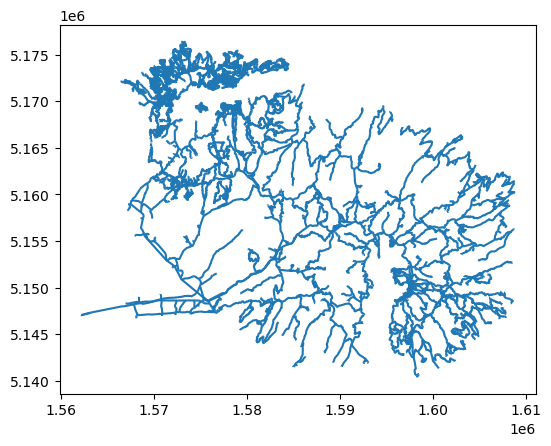

In [20]:
unidirectional_edges.plot()